In [9]:
import os, cv2, random, numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt


In [ ]:
# import os

# DATA_PATH = r"C:\Image Recognition\data"
# KEEP = 3000

# files = sorted(os.listdir(DATA_PATH))

# print("Total images:", len(files))

# # images to delete
# delete_files = files[KEEP:]

# for f in delete_files:
#     os.remove(os.path.join(DATA_PATH, f))

# print("Remaining images:", len(os.listdir(DATA_PATH)))
# print("Done ✔️")


In [11]:
def add_gaussian_noise(img):
    mean = 0
    std = random.uniform(5,25)
    noise = np.random.normal(mean,std,img.shape).astype(np.float32)
    return np.clip(img.astype(np.float32)+noise,0,255).astype(np.uint8)

def add_blur(img):
    return cv2.GaussianBlur(img,(5,5),0)

def add_lowres(img):
    h,w = img.shape[:2]
    small = cv2.resize(img,(w//3,h//3))
    return cv2.resize(small,(w,h))

def corrupt_image(img):
    return random.choice([add_gaussian_noise,add_blur,add_lowres])(img)


In [12]:
class RAImageDataset(Dataset):
    def __init__(self, root_dir, img_size=128):
        self.paths = [os.path.join(root_dir,f) for f in os.listdir(root_dir)]

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size,img_size))
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]

        clean = cv2.imread(path)
        clean = cv2.cvtColor(clean,cv2.COLOR_BGR2RGB)

        corrupted = corrupt_image(clean.copy())

        clean = self.transform(clean)
        corrupted = self.transform(corrupted)

        return corrupted, clean, 0


In [13]:
dataset = RAImageDataset(DATA_PATH)
loader = DataLoader(dataset,batch_size=4,shuffle=True)

print("Dataset size:",len(dataset))


Dataset size: 3000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0196054..1.0000001].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.017958146..1.0000001].


Text(0.5, 1.0, 'Clean')

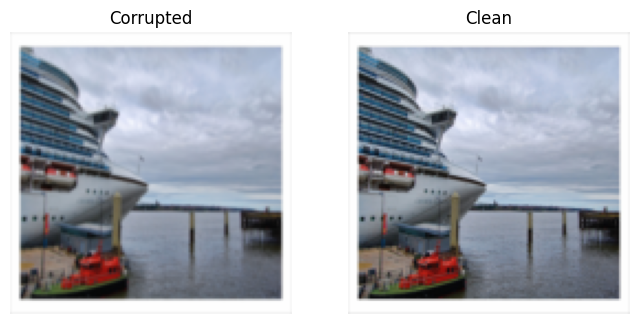

In [16]:
corrupted, clean, _ = next(iter(loader))

def show(img):
    plt.imshow(img.permute(1,2,0))
    plt.axis("off")

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); show(corrupted[0]); plt.title("Corrupted")
plt.subplot(1,2,2); show(clean[0]); plt.title("Clean")
